<a href="https://www.kaggle.com/code/beyzadurduu/catboostclassifier?scriptVersionId=346119680" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

### CatBoost Classifier

CatBoostClassifier, Yandex tarafından geliştirilmiş, Gradient Boosting (gradyan artırma) temeline dayanan açık kaynaklı güçlü bir karar ağacı sınıflandırma algoritmasıdır. Adındaki "Cat" ifadesi Categorical (kategorik), "Boost" ifadesi ise Boosting kelimelerinden gelir.

Tablo tipi (tabular) verilerde, özellikle içerisinde çok sayıda metin veya kategorik sütun barındıran veri kümelerinde yüksek doğruluk ve hız sunar.

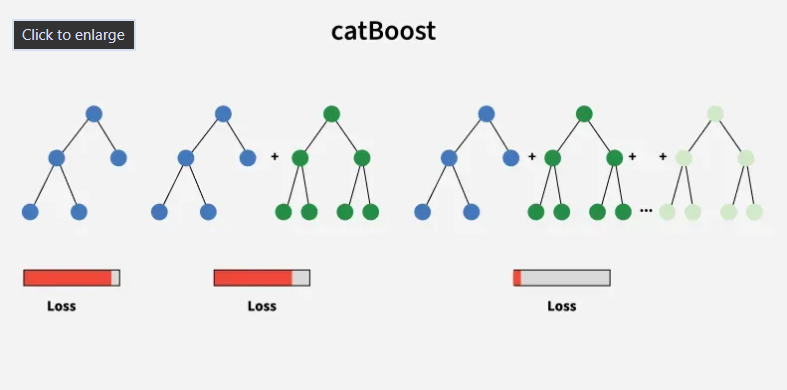

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/miadul/hospital-readmission-risk-dataset/hospital_readmission_risk_10000.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/miadul/hospital-readmission-risk-dataset/hospital_readmission_risk_10000.csv")
df.head(3)

,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
0,d8fd1a56-a5d8-499b-917c-f9ac8d369f9b,18,Male,57,157,23.1,8,Heart Disease,8,16.2,...,7,0,Current,Moderate,Medium,Private,Poor,Weak,Yes,Medium
1,2e9b4349-69e5-494f-b806-947ec5b5bb7c,23,Female,117,150,52.0,6,Diabetes,6,13.1,...,21,2,Never,High,Medium,Private,Good,Weak,Yes,High
2,6f279c22-3b20-4328-9dac-466de7c47a51,80,Female,61,141,30.7,5,Heart Disease,8,15.4,...,2,0,Never,Moderate,Low,Public,Good,Weak,No,Low


In [3]:
df=df.drop("patient_id",axis=1)
df.head(3)

,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,last_glucose,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
0,18,Male,57,157,23.1,8,Heart Disease,8,16.2,135.1,...,7,0,Current,Moderate,Medium,Private,Poor,Weak,Yes,Medium
1,23,Female,117,150,52.0,6,Diabetes,6,13.1,137.2,...,21,2,Never,High,Medium,Private,Good,Weak,Yes,High
2,80,Female,61,141,30.7,5,Heart Disease,8,15.4,82.1,...,2,0,Never,Moderate,Low,Public,Good,Weak,No,Low


In [4]:
df=pd.get_dummies(df,columns=["gender","chronic_conditions","smoking_status","alcohol_use","physical_activity","insurance_type","followup_compliance","social_support","mental_health_issue","admission_type"],drop_first=True)

In [5]:
df.head(3)

,age,weight_kg,height_cm,bmi,num_previous_admissions,medications_count,last_hemoglobin,last_glucose,last_creatinine,length_of_stay,...,alcohol_use_Moderate,physical_activity_Low,physical_activity_Medium,insurance_type_Public,insurance_type_Uninsured,followup_compliance_Poor,social_support_Weak,mental_health_issue_Yes,admission_type_Emergency,admission_type_Urgent
0,18,57,157,23.1,8,8,16.2,135.1,0.96,7,...,True,False,True,False,False,True,True,True,True,False
1,23,117,150,52.0,6,6,13.1,137.2,1.11,21,...,False,False,True,False,False,False,True,True,False,False
2,80,61,141,30.7,5,8,15.4,82.1,0.71,2,...,True,True,False,True,False,False,True,False,False,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               9999 non-null   int64  
 1   weight_kg                         9999 non-null   int64  
 2   height_cm                         9999 non-null   int64  
 3   bmi                               9999 non-null   float64
 4   num_previous_admissions           9999 non-null   int64  
 5   medications_count                 9999 non-null   int64  
 6   last_hemoglobin                   9999 non-null   float64
 7   last_glucose                      9999 non-null   float64
 8   last_creatinine                   9999 non-null   float64
 9   length_of_stay                    9999 non-null   int64  
 10  procedures_count                  9999 non-null   int64  
 11  readmission_risk                  9999 non-null   object 
 12  gender

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
y=df["readmission_risk"]
x=df.drop(columns=["readmission_risk"],axis=1)

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [10]:
from catboost import CatBoostClassifier

In [11]:
cb = CatBoostClassifier(
    iterations=1000,       # Eğitilecek toplam karar ağacı (iterasyon/adım) sayısıdır; modelin veriyi kaç adımda öğreneceğini belirler.
    learning_rate=0.05,    # Öğrenme hızı/oranıdır; her yeni ağacın toplam modele ne kadar katkı yapacağını (adım büyüklüğünü) kontrol eder.
    depth=6,               # Karar ağaçlarının maksimum derinliğidir; her bir ağacın kaç katman dallanacağını ve özellikler arası etkileşim karmaşıklığını belirler.
    verbose=100            # Eğitim sırasında çıktı sıklığıdır; kaybın (loss) ve metriklerin her 100 adımda bir ekrana yazdırılmasını sağlar.
)


In [12]:
model=cb.fit(x_train,y_train)

0:	learn: 1.0980778	total: 64ms	remaining: 1m 3s
100:	learn: 1.0510799	total: 822ms	remaining: 7.32s
200:	learn: 1.0121252	total: 1.58s	remaining: 6.3s
300:	learn: 0.9751446	total: 2.34s	remaining: 5.45s
400:	learn: 0.9393518	total: 3.1s	remaining: 4.63s
500:	learn: 0.9044694	total: 3.85s	remaining: 3.84s
600:	learn: 0.8708328	total: 4.62s	remaining: 3.07s
700:	learn: 0.8391341	total: 5.42s	remaining: 2.31s
800:	learn: 0.8094124	total: 6.19s	remaining: 1.54s
900:	learn: 0.7821065	total: 6.96s	remaining: 765ms
999:	learn: 0.7554642	total: 7.72s	remaining: 0us


In [13]:
model.score(x_test,y_test)

np.float64(0.334)